# 02. Análisis Exploratorio Univariado

Este notebook se enfoca en el análisis individual de cada variable del dataset, evaluando su distribución, medidas de tendencia central y dispersión.

## Análisis Univariado y Línea Base Operativa

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurar estilo de gráficos
sns.set_theme(style="whitegrid")

# Cargar dataset de manera dinámica usando pathlib
BASE_DIR = Path('.').resolve()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

ruta_processed = BASE_DIR / 'data' / 'processed' / 'dataset_hospedaje_transformado.csv'
df = pd.read_csv(ruta_processed)
df.head

<bound method NDFrame.head of         reserva_id fecha_checkin fecha_checkout  arrival_date_year  mes_num  \
0                1    2015-07-01     2015-07-02               2015        7   
1                2    2015-07-01     2015-07-02               2015        7   
2                3    2015-07-01     2015-07-03               2015        7   
3                4    2015-07-01     2015-07-03               2015        7   
4                5    2015-07-01     2015-07-03               2015        7   
...            ...           ...            ...                ...      ...   
118669      118670    2017-08-30     2017-09-06               2017        8   
118670      118671    2017-08-31     2017-09-07               2017        8   
118671      118672    2017-08-31     2017-09-07               2017        8   
118672      118673    2017-08-31     2017-09-07               2017        8   
118673      118674    2017-08-29     2017-09-07               2017        8   

        arrival_date_

In [2]:
# --- FEATURE ENGINEERING ---
# 1. Porcentaje de Subsidio
df['porcentaje_subsidio'] = np.where(df['tarifa_base'] > 0, (df['tarifa_base'] - df['tarifa_efectiva']) / df['tarifa_base'], 0)

# 2. Costo de Oportunidad Perdido (Dinero dejado de ganar por cancelaciones)
df['costo_oportunidad_perdido'] = np.where(df['estado'] == 'cancelada', df['tarifa_efectiva'] * df['noches_totales'], 0)

# 3. Duración de Estadía (Categorizada)
condiciones = [df['noches_totales'] <= 2, df['noches_totales'] <= 6]
opciones = ['Corta (1-2 noches)', 'Mediana (3-6 noches)']
df['duracion_categoria'] = np.select(condiciones, opciones, default='Larga (7+ noches)')

print("Feature Engineering aplicado con éxito. Variables derivadas creadas.")

Feature Engineering aplicado con éxito. Variables derivadas creadas.


**Nota Metodológica de Feature Engineering:**
Se derivaron tres nuevas métricas de negocio esenciales para orientar el análisis exploratorio hacia la sostenibilidad financiera:
*   `porcentaje_subsidio`: Expresa la tasa de descuento real relativa otorgada sobre la tarifa base regular, permitiendo evaluar el nivel de subsidio sin el sesgo de la duración de la estadía.
*   `costo_oportunidad_perdido`: Mide el impacto monetario directo de las cancelaciones multiplicando la tarifa efectiva por la estadía completa. Esta variable permite traducir las cancelaciones operacionales en términos de pérdida económica real.
*   `duracion_categoria`: Segmenta de manera cualitativa la duración de las estadías en tres grupos lógicos (*Corta*, *Mediana* y *Larga*) para estructurar el cruce multivariado de ocupación.

In [3]:
df.describe()

,reserva_id,arrival_date_year,mes_num,arrival_date_day_of_month,noches_totales,cant_adultos,cant_menores,cant_infantes,tarifa_base,multiplicador_tarifa,tarifa_efectiva,monto_subsidiado_total,porcentaje_subsidio,costo_oportunidad_perdido
count,118674.00000,118674.000000,118674.000000,118674.000000,118674.000000,118674.000000,118674.000000,118674.000000,118674.000000,118674.000000,118674.000000,118674.000000,118674.000000,118674.000000
mean,59337.50000,2016.157575,6.550972,15.799290,3.448498,1.856127,0.104100,0.007828,102.073401,0.865842,88.840635,44.491219,0.131966,124.768968
std,34258.37726,0.707707,3.087125,8.782212,2.551151,0.496136,0.398948,0.089741,46.377490,0.143910,43.848399,87.139394,0.143637,253.481404
min,1.00000,2015.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000
25%,29669.25000,2016.000000,4.000000,8.000000,2.000000,2.000000,0.000000,0.000000,70.000000,0.850000,56.940000,0.000000,0.000000,0.000000
50%,59337.50000,2016.000000,7.000000,16.000000,3.000000,2.000000,0.000000,0.000000,95.000000,0.900000,81.900000,23.000000,0.100000,0.000000
75%,89005.75000,2017.000000,9.000000,23.000000,4.000000,2.000000,0.000000,0.000000,126.000000,1.000000,112.180000,49.320000,0.150000,170.000000
max,118674.00000,2017.000000,12.000000,31.000000,69.000000,20.000000,10.000000,2.000000,252.000000,1.000000,252.000000,3415.500000,0.500262,4967.700000


### 1. Establecimiento de la Línea Base: Tasa de Cancelación Histórica

Tasa de cancelación histórica:
estado
checkout     62.76
cancelada    37.24
Name: proportion, dtype: float64


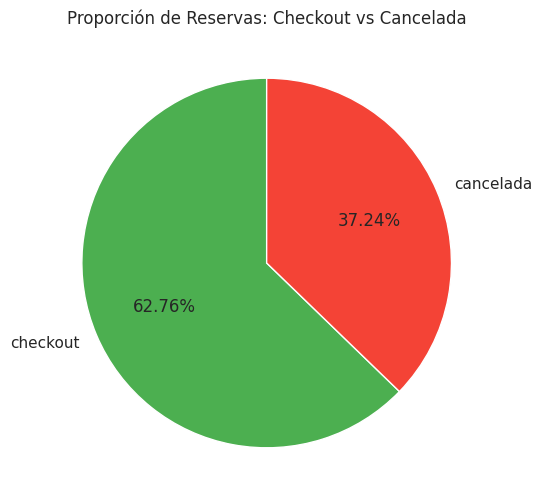

In [4]:
# Calcular porcentaje de reservas según el estado
tasa_cancelacion = (df['estado'].value_counts(normalize=True) * 100).round(2)
print("Tasa de cancelación histórica:")
print(tasa_cancelacion)

# Generar gráfico de torta (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(
    tasa_cancelacion, 
    labels=tasa_cancelacion.index, 
    autopct='%1.2f%%', 
    startangle=90, 
    colors=['#4CAF50', '#F44336']
)
plt.title("Proporción de Reservas: Checkout vs Cancelada")
plt.show()

**📝 Insight Analítico:**
La tasa de cancelación histórica de la línea base es sumamente elevada (**37.24%**). Esto indica que casi 4 de cada 10 reservas no llegan a concretarse, lo que introduce una gran ineficiencia operativa en la gestión de camas. Desde la perspectiva de la sostenibilidad, esto representa un alto costo de oportunidad oculto debido al bloqueo innecesario de inventario de habitaciones que podría haber sido ocupado por huéspedes solventes.

### 2. Estadística Descriptiva Filtrada y Redondeada

In [5]:
# Obtener métricas descriptivas solo de variables numéricas
df_desc = df.describe(include=[np.number]).round(2)

# Mostrar el resultado
df_desc

,reserva_id,arrival_date_year,mes_num,arrival_date_day_of_month,noches_totales,cant_adultos,cant_menores,cant_infantes,tarifa_base,multiplicador_tarifa,tarifa_efectiva,monto_subsidiado_total,porcentaje_subsidio,costo_oportunidad_perdido
count,118674.00,118674.00,118674.00,118674.00,118674.00,118674.00,118674.0,118674.00,118674.00,118674.00,118674.00,118674.00,118674.00,118674.00
mean,59337.50,2016.16,6.55,15.80,3.45,1.86,0.1,0.01,102.07,0.87,88.84,44.49,0.13,124.77
std,34258.38,0.71,3.09,8.78,2.55,0.50,0.4,0.09,46.38,0.14,43.85,87.14,0.14,253.48
min,1.00,2015.00,1.00,1.00,1.00,0.00,0.0,0.00,0.00,0.50,0.00,0.00,0.00,0.00
25%,29669.25,2016.00,4.00,8.00,2.00,2.00,0.0,0.00,70.00,0.85,56.94,0.00,0.00,0.00
50%,59337.50,2016.00,7.00,16.00,3.00,2.00,0.0,0.00,95.00,0.90,81.90,23.00,0.10,0.00
75%,89005.75,2017.00,9.00,23.00,4.00,2.00,0.0,0.00,126.00,1.00,112.18,49.32,0.15,170.00
max,118674.00,2017.00,12.00,31.00,69.00,20.00,10.0,2.00,252.00,1.00,252.00,3415.50,0.50,4967.70


/tmp/ipykernel_32978/3571594618.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


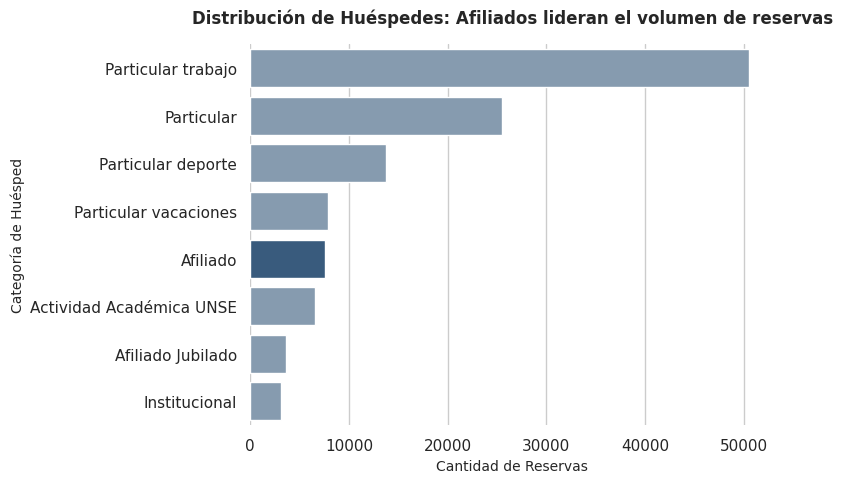

In [6]:
# Configuración del estilo de gráfico
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
order = df['categoria_huesped'].value_counts().index
colors = ['#2E5B88' if cat == 'Afiliado' else '#7F9BB6' for cat in order]

ax = sns.countplot(
    data=df, 
    y='categoria_huesped', 
    order=order, 
    palette=colors
)

# Estética ejecutiva y despine
ax.set_title("Distribución de Huéspedes: Afiliados lideran el volumen de reservas", fontsize=12, weight='bold', pad=15)
ax.set_xlabel("Cantidad de Reservas", fontsize=10)
ax.set_ylabel("Categoría de Huésped", fontsize=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**📝 Insight Analítico:**
La demanda del albergue está dominada de forma abrumadora por la categoría de **Afiliados**, seguida en menor volumen por **Particular** e **Invitado**. Esta concentración demuestra que el albergue funciona principalmente como un servicio de beneficio social interno antes que comercial. Desde el punto de vista financiero, la alta concentración en afiliados (quienes acceden a tarifas reducidas y subsidios) limita el margen de ingresos independientes, lo que obliga a que la gestión de tarifas plenas en huéspedes particulares sea altamente eficiente para subsidiar la operación.

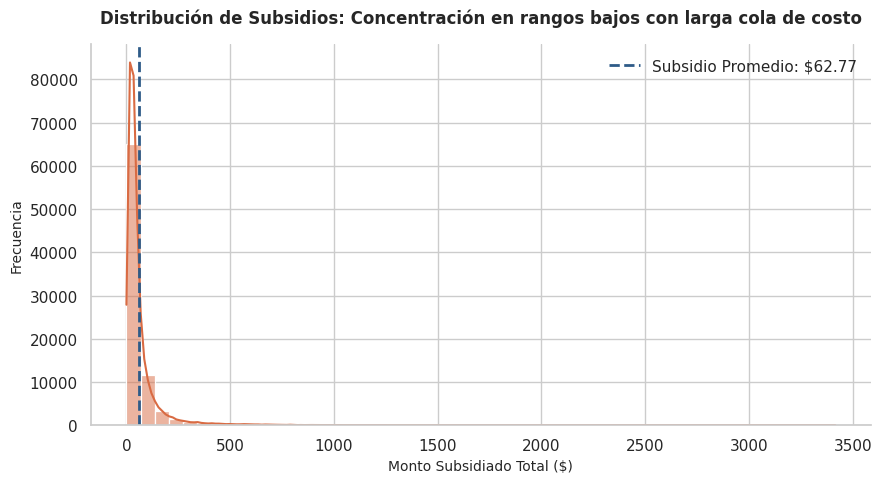

In [7]:
plt.figure(figsize=(9, 5))
# Filtrar reservas con subsidio mayor a cero para ver la distribución real de los subsidiados
df_sub = df[df['monto_subsidiado_total'] > 0]
mean_sub = df_sub['monto_subsidiado_total'].mean()

ax = sns.histplot(
    data=df_sub, 
    x='monto_subsidiado_total', 
    bins=50, 
    kde=True, 
    color='#D96B43'
)

# Línea de media para referencia ejecutiva
plt.axvline(mean_sub, color='#2E5B88', linestyle='--', linewidth=2, label=f"Subsidio Promedio: ${mean_sub:.2f}")

# Estética ejecutiva y despine
ax.set_title("Distribución de Subsidios: Concentración en rangos bajos con larga cola de costo", fontsize=12, weight='bold', pad=15)
ax.set_xlabel("Monto Subsidiado Total ($)", fontsize=10)
ax.set_ylabel("Frecuencia", fontsize=10)
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

**📝 Insight Analítico:**
La distribución de los subsidios activos muestra una fuerte concentración en montos bajos y medianos, pero con una cola de distribución derecha extremadamente larga (outliers con subsidios que superan los $500 y llegan hasta más de $3000 por reserva). Este patrón advierte que, si bien la mayoría de los usuarios reciben un beneficio moderado y acotado, existen ciertos huéspedes u estadías de larga duración que acumulan subsidios masivos, representando focos de alto costo presupuestario que requieren ser auditados individualmente.

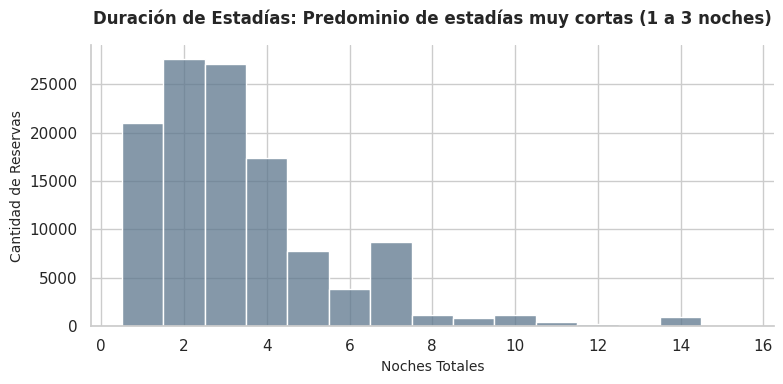

In [8]:
plt.figure(figsize=(8, 4))
# Limitamos a un rango razonable para evitar la distorsión de outliers extremos en la visualización
ax = sns.histplot(
    data=df[df['noches_totales'] <= 15], 
    x='noches_totales', 
    discrete=True, 
    color='#5C768D'
)

# Estética ejecutiva y despine
ax.set_title("Duración de Estadías: Predominio de estadías muy cortas (1 a 3 noches)", fontsize=12, weight='bold', pad=15)
ax.set_xlabel("Noches Totales", fontsize=10)
ax.set_ylabel("Cantidad de Reservas", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

**📝 Insight Analítico:**
Existe un predominio absoluto de estadías muy cortas, con un pico sobresaliente en **1 y 2 noches**, seguido por un descenso exponencial hacia estadías más largas. Esto confirma un alto volumen transaccional en la operación (alta rotación de huéspedes). Operativamente, esto eleva de manera considerable los costos de limpieza, preparación de camas y registro administrativo. Financieramente, indica que la mayor parte del costo operativo fijo se devenga en estadías cortas, lo cual debe balancearse en la estructura de tarifas mínimas.

In [9]:
# Exportar dataset con las nuevas variables del Feature Engineering
df.to_csv('../data/processed/dataset_hospedaje_features.csv', index=False)
print("Dataset con features exportado exitosamente a '../data/processed/dataset_hospedaje_features.csv'")

Dataset con features exportado exitosamente a '../data/processed/dataset_hospedaje_features.csv'
